In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster
import importlib
importlib.reload(nue_booster)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [ ]:
# split_type = 'simple'
split_type = 'mc_query'
# split_type = 'mc_nue_query'

In [4]:
RUN = ["4a_nuepresel","4b_nuepresel","4c_nuepresel","4d_nuepresel","5_nuepresel"]

# Use truth filters for 'simple' split
if split_type == 'simple':
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=True,
        loadpi0variables=True,
        loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        loadnumuvariables=True,
        use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
        use_numi=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,             # Set blinded to true, no training on data!!
    )

# Don't use truth filters for query split
if split_type == 'mc_query' or split_type == 'mc_nue_query':
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=False,
        loadpi0variables=True,
        loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        loadnumuvariables=True,
        use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
        use_numi=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,             # Set blinded to true, no training on data!!
    )

Loading run 4a_nuepresel
Loading run 4b_nuepresel
Loading run 4c_nuepresel
Loading run 4d_nuepresel
Loading run 5_nuepresel


In [5]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [6]:
# import pandas as pd

# pd.set_option('display.max_rows', None)

# print(df_nu["nu_pdg"])

In [7]:
# print(df_nue["is_signal"])
# print(df_nue["category"])
# print(df_nu)

In [8]:
# Split dataframes into training and testing samples according to split_type
if split_type == 'simple':
    train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
    train_nue, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
    train_ncpi0, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

if split_type == 'mc_query':
    train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

if split_type == 'mc_nue_query':
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

In [ ]:
# For either type of query, separate double counted truth events
if split_type == 'mc_query' or split_type == 'mc_nue_query':
    # Separate CC Nue events from nu overlay
    NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
    nu_ccnue = df_nu.query(NUEQUERY)

    # Separate NC Pi0 events from nu overlay
    NCPI0QUERY = '(mcf_pass_ncpi0==1)'
    nu_ncpi0 = df_nu.query(NCPI0QUERY)

    # Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
    MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
    nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

    # Split this new nu overlay sample into training and testing samples
    train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.5, random_state=1990)

    # Add the nu overlay NC pi0 events to the NC pi0 training sample
    train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)
    
# For MC query split only, add the nu overlay CC nue events to the nue truth training sample
if split_type == 'mc_query':
    train_nue = pd.concat([train_nue_truth, nu_ccnue], ignore_index=True)

In [10]:
if split_type == 'mc_nue_query':
    ZPQUERY = 'category==10'
    NPQUERY = 'category==11'
    NUEOTHERQUERY = '(category!=10 & category!=11)'

    # Split nue overlay into three different nue categories
    zp_nue = df_nue.query(ZPQUERY)
    np_nue = df_nue.query(NPQUERY)
    other_nue = df_nue.query(NUEOTHERQUERY)

    # Split nu overlay CC nue samples into different nue categories 
    zp_nu_ccnue = nu_ccnue.query(ZPQUERY)
    np_nu_ccnue = nu_ccnue.query(NPQUERY)
    other_nu_ccnue = nu_ccnue.query(NUEOTHERQUERY)

    # Choose signal definition
    nue_signal = 'ZP'
    # nue_signal = 'ZP_NP'

    if nue_signal == 'ZP':
        # Define signal and background nue samples
        signal_nue = zp_nue
        bkg_nue = pd.concat([np_nue, other_nue], ignore_index=True)

        # Define signal and background nue events from nu overlay sample
        signal_nu_ccnue = zp_nu_ccnue
        bkg_nu_ccnue = pd.concat([np_nu_ccnue, other_nu_ccnue], ignore_index=True)

    if nue_signal == 'ZP_NP':
        signal_nue = pd.concat([zp_nue, np_nue], ignore_index=True)
        bkg_nue = other_nue

        signal_nu_ccnue = pd.concat([zp_nu_ccnue, np_nu_ccnue])
        bkg_nu_ccnue = other_nu_ccnue

    # Split signal and background nue samples
    train_signal_df_nue, test_signal_nue = train_test_split(signal_nue, test_size=0.5, random_state=1990)
    train_bkg_df_nue, test_bkg_nue = train_test_split(bkg_nue, test_size=0.5, random_state=1990)

    # Concatenate nu overlay CC nue events into their respective nue overlay training samples
    train_signal_nue = pd.concat([train_signal_df_nue, signal_nu_ccnue], ignore_index=True)
    train_bkg_nue = pd.concat([train_bkg_df_nue, bkg_nu_ccnue], ignore_index=True)

In [11]:
# print(nu_ccnue["nu_pdg"])

# print(nu_ncpi0["nu_pdg"])

# print(train_nu["nu_pdg"])

In [12]:
# train_nu_25p, test_nu_25p = train_test_split(test_nu, test_size = 0.5, random_state=1990)
# train_nue_25p, test_nue_25p = train_test_split(test_nue, test_size = 0.5, random_state=1990)
# train_dirt_25p, test_dirt_25p = train_test_split(test_dirt, test_size = 0.5, random_state=1990)
# train_ncpi0_25p, test_ncpi0_25p = train_test_split(test_ncpi0, test_size = 0.5, random_state=1990)
# train_ext_25p, test_ext_25p = train_test_split(test_ext, test_size = 0.5, random_state=1990)

In [13]:
# test_nue.to_csv(os.path.join("/exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/bdt", "run45_train_nue.csv"), index=False)

In [14]:
if split_type == 'mc_nue_query':
    samples = {
        "mc": (train_nu, test_nu),
        "nue_signal": (train_signal_nue, test_signal_nue),
        "nue_bkg": (train_bkg_nue, test_bkg_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

if split_type == 'simple' or split_type == 'mc_query':
    samples = {
        "mc": (train_nu, test_nu),
        "nue": (train_nue, test_nue),
        "dirt": (train_dirt, test_dirt),
        "ncpi0": (train_ncpi0, test_ncpi0),
        "ext": (train_ext, test_ext),
    }

# samples = {
#     "mc": (train_nu_25p, test_nu_25p),
#     "nue": (train_nue_25p, test_nue_25p),
#     "dirt": (train_dirt_25p, test_dirt_25p),
#     "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
#     "ext": (train_ext_25p, test_ext_25p),
# }

In [15]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`


In [16]:
# Inclusive set of variables w/ NuGraph
TRAINVAR = [
    "shrmoliereavg",
    "shr_score",
    "trkfit",
    "subcluster",
    "CosmicIPAll3D",
    "CosmicDirAll3D",
    "shrMCSMom",
    "DeltaRMS2h",
    "shrPCA1CMed_5cm",
    "CylFrac2h_1cm",    
    "shr_tkfit_2cm_dedx_Y",
    "shr_tkfit_2cm_dedx_U",
    "shr_tkfit_2cm_dedx_V",
    "shr_tkfit_gap10_dedx_Y",
    "shr_tkfit_gap10_dedx_U",
    "shr_tkfit_gap10_dedx_V",
    "shr_tkfit_dedx_max",
    "secondshower_U_nhit",
    "secondshower_U_vtxdist",
    "secondshower_U_dot",
    "secondshower_U_dir",
    "anglediff_U",
    "secondshower_V_nhit",
    "secondshower_V_vtxdist",
    "secondshower_V_dot",
    "secondshower_V_dir",
    "anglediff_V",
    "secondshower_Y_nhit",
    "secondshower_Y_vtxdist",
    "secondshower_Y_dot",
    "secondshower_Y_dir",
    "anglediff_Y",
    "slcng2mip",
    "slcng2hip",
    "slcng2shr",
    "slcng2mcl",
    "slcng2dfs",
    "slcng2bkg",
    "clung2mip",
    "clung2hip",
    "clung2shr",
    "clung2mcl",
    "clung2dfs",
    "clung2bkg",
    "nhits_r1cm",
    "nhits_r3cm",
    "nhits_r5cm",
    "nhits_r10cm",
    "diffY","normdiffY","diffZ","normdiffZ","fnl",
    "is_signal","train_weight","nu_e"
]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [17]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl', 'is_signa

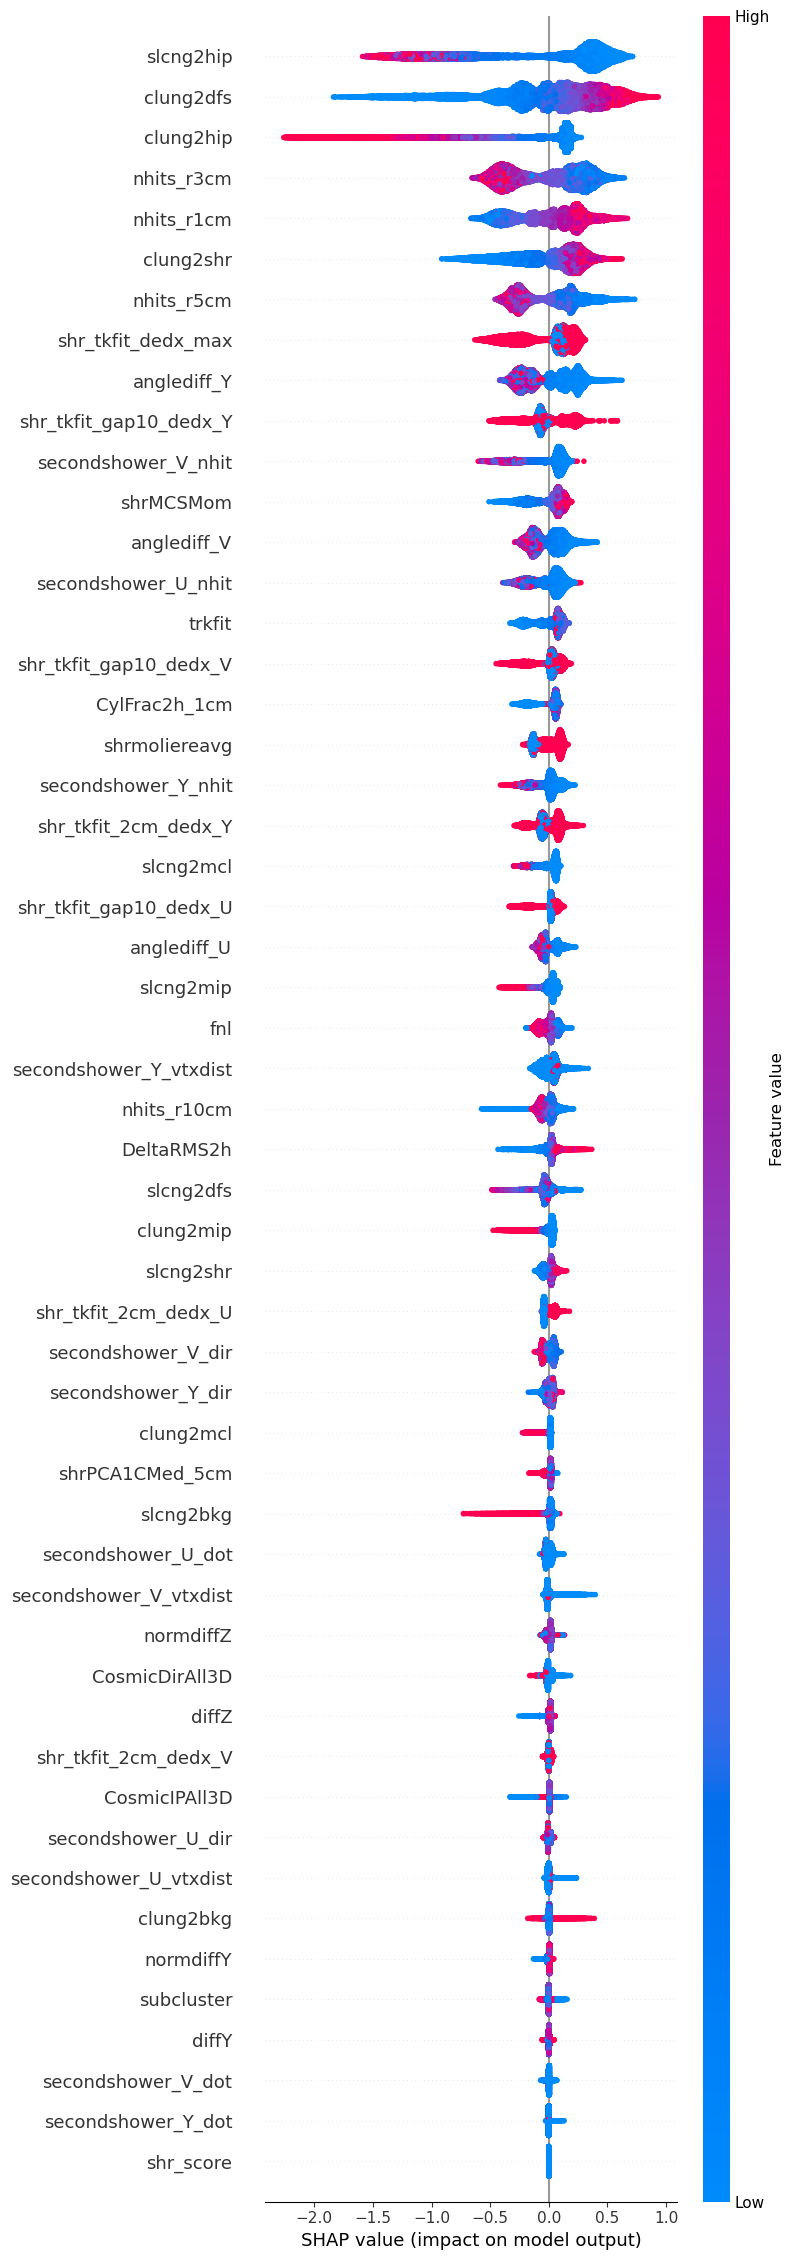

area under the precision-recall curve: 0.810593
precision score: 0.769499
recall score: 0.683002
Importance (total_gain):
slcng2hip 90527.14714290103
anglediff_Y 34028.33777000001
clung2dfs 32792.865744423005
shr_tkfit_dedx_max 30290.52101988001
shr_tkfit_gap10_dedx_Y 29658.54871888
nhits_r5cm 29540.44494534002
clung2shr 26578.541629789997
clung2hip 20948.104260306987
nhits_r3cm 20629.418983730004
shrMCSMom 16628.312339667995
nhits_r1cm 16011.465867684003
secondshower_V_nhit 14990.664454570013
secondshower_U_nhit 11452.903661529008
anglediff_V 10110.868352120006
shr_tkfit_2cm_dedx_Y 9064.111343900002
secondshower_Y_nhit 7604.259390020001
nhits_r10cm 6793.554950620001
slcng2mcl 6766.904042249998
shr_tkfit_gap10_dedx_V 5804.382378448007
slcng2mip 5534.630834320002
shrmoliereavg 5530.902052859
secondshower_Y_vtxdist 4664.619547189998
slcng2bkg 4662.895174939999
trkfit 4534.3713538782
CylFrac2h_1cm 3739.9087035870016
anglediff_U 3684.584317389999
shr_tkfit_gap10_dedx_U 3268.3669506799997
s

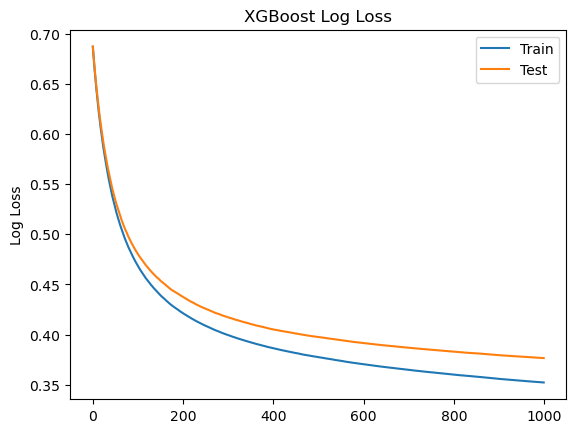

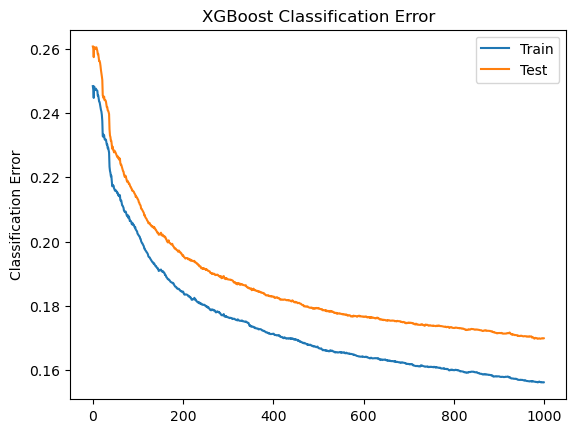

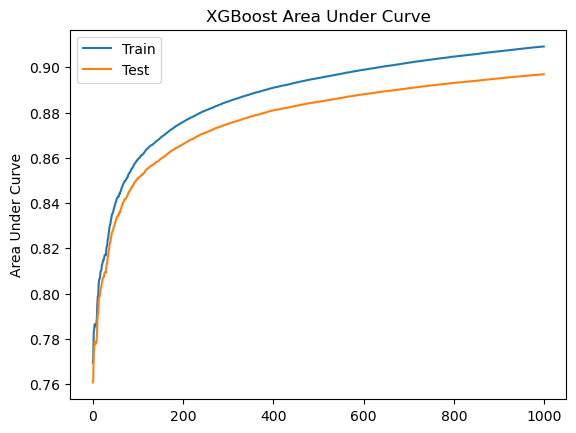

Training pi0...
&category!=10 and npi0>0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


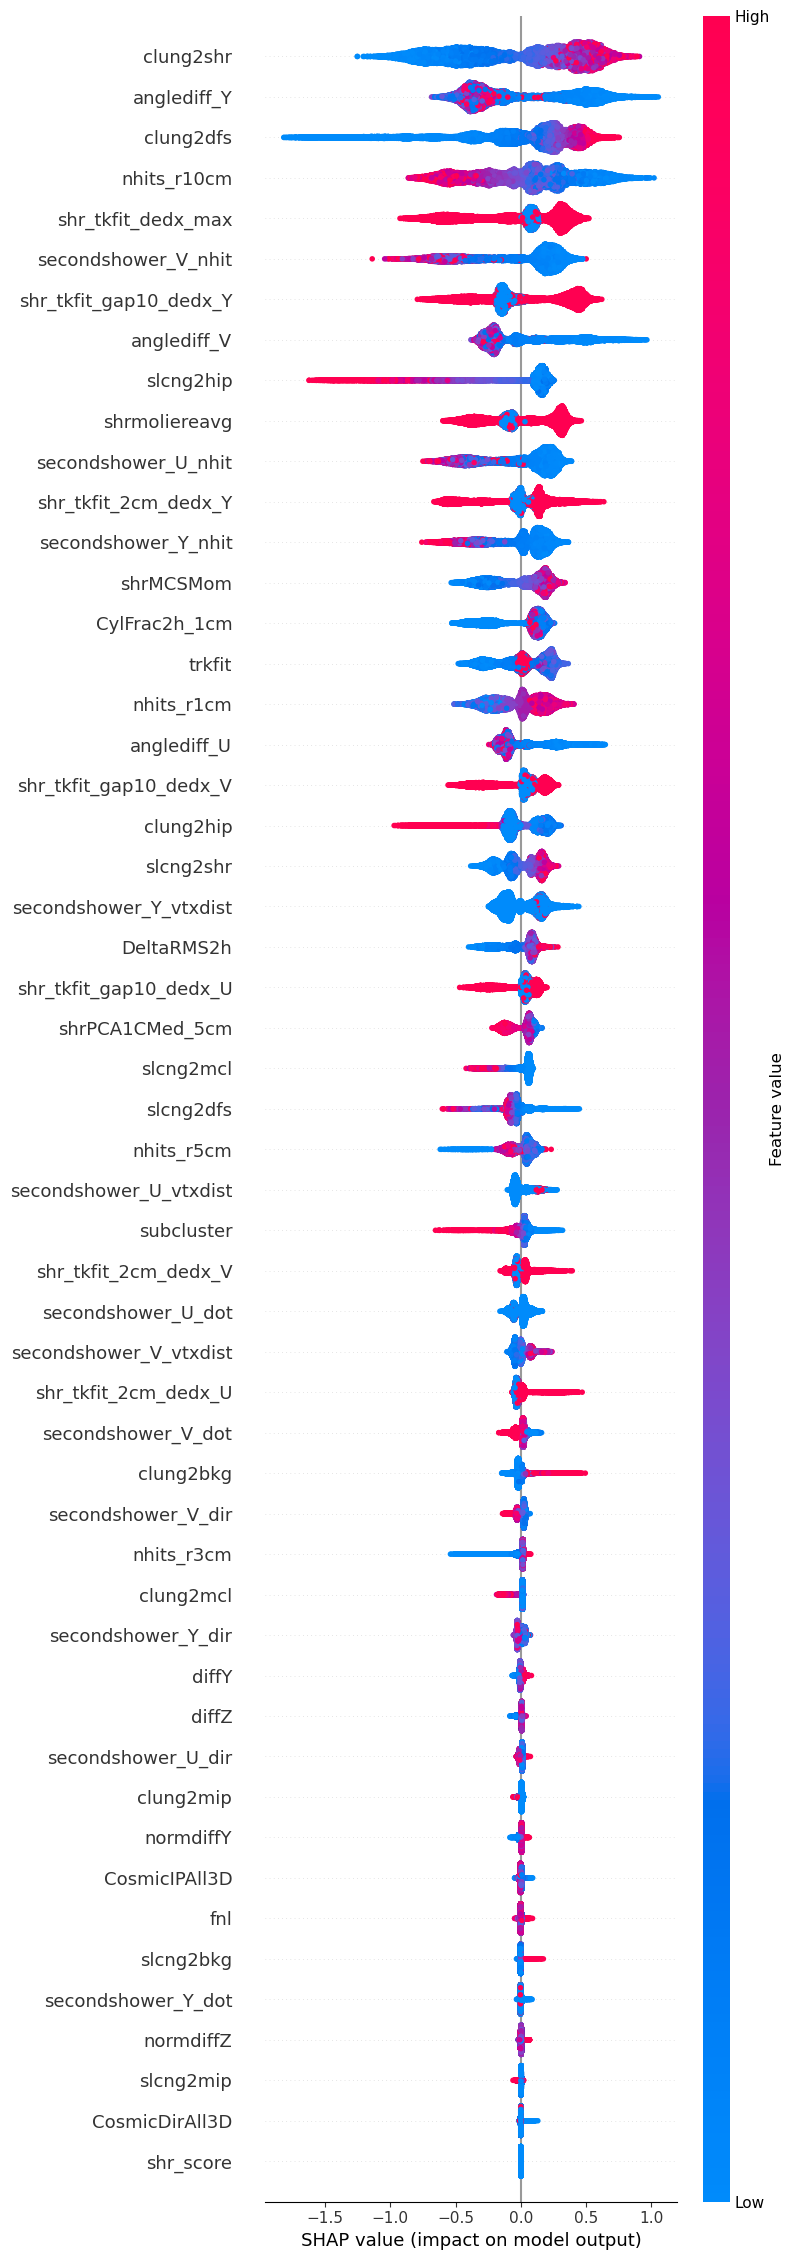

area under the precision-recall curve: 0.961180
precision score: 0.891241
recall score: 0.898147
Importance (total_gain):
anglediff_Y 55356.114048731004
clung2shr 43029.87612219998
shr_tkfit_gap10_dedx_Y 38763.18980473001
shr_tkfit_dedx_max 35781.52806359999
nhits_r10cm 31210.897793180025
secondshower_V_nhit 29636.68629292999
slcng2hip 24101.593170000007
clung2dfs 21449.917837812973
secondshower_U_nhit 21113.62958412998
shrMCSMom 20244.60120424999
anglediff_V 19939.382489219992
shr_tkfit_2cm_dedx_Y 17671.7584643
shrmoliereavg 16023.122677431009
secondshower_Y_nhit 13328.268390659998
CylFrac2h_1cm 9580.59136213001
anglediff_U 8824.166447289994
shr_tkfit_gap10_dedx_V 7772.571257570002
trkfit 7163.734120520005
clung2hip 6962.554005610996
secondshower_Y_vtxdist 5951.261365429995
nhits_r1cm 5948.0449025700045
nhits_r5cm 5592.895183509998
slcng2shr 4647.876576130002
slcng2dfs 4523.56303603
shr_tkfit_gap10_dedx_U 3812.6324955099985
slcng2mcl 2885.0367286399996
shr_tkfit_2cm_dedx_V 2790.162312

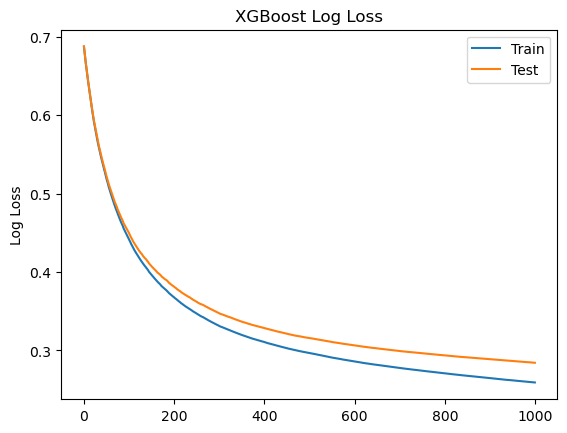

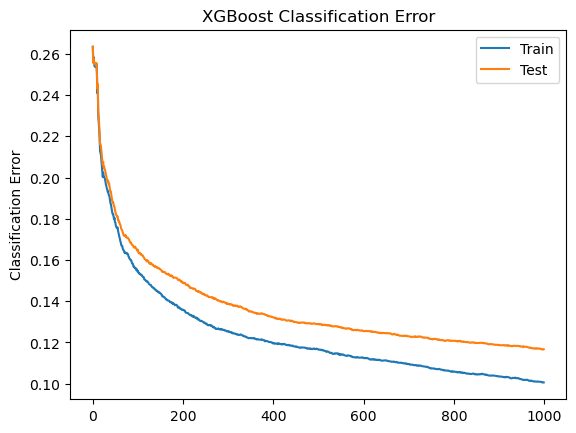

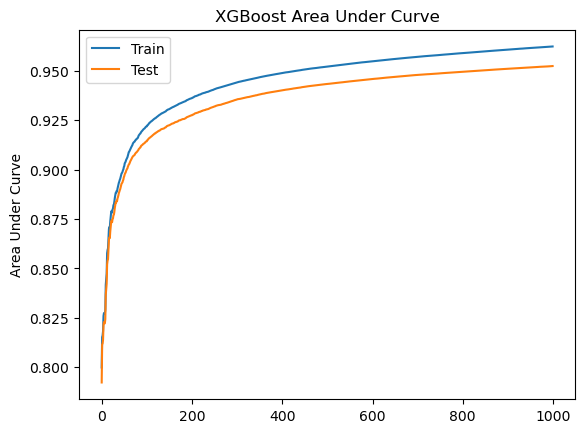

Training nonpi0...
&category!=10 and npi0==0
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


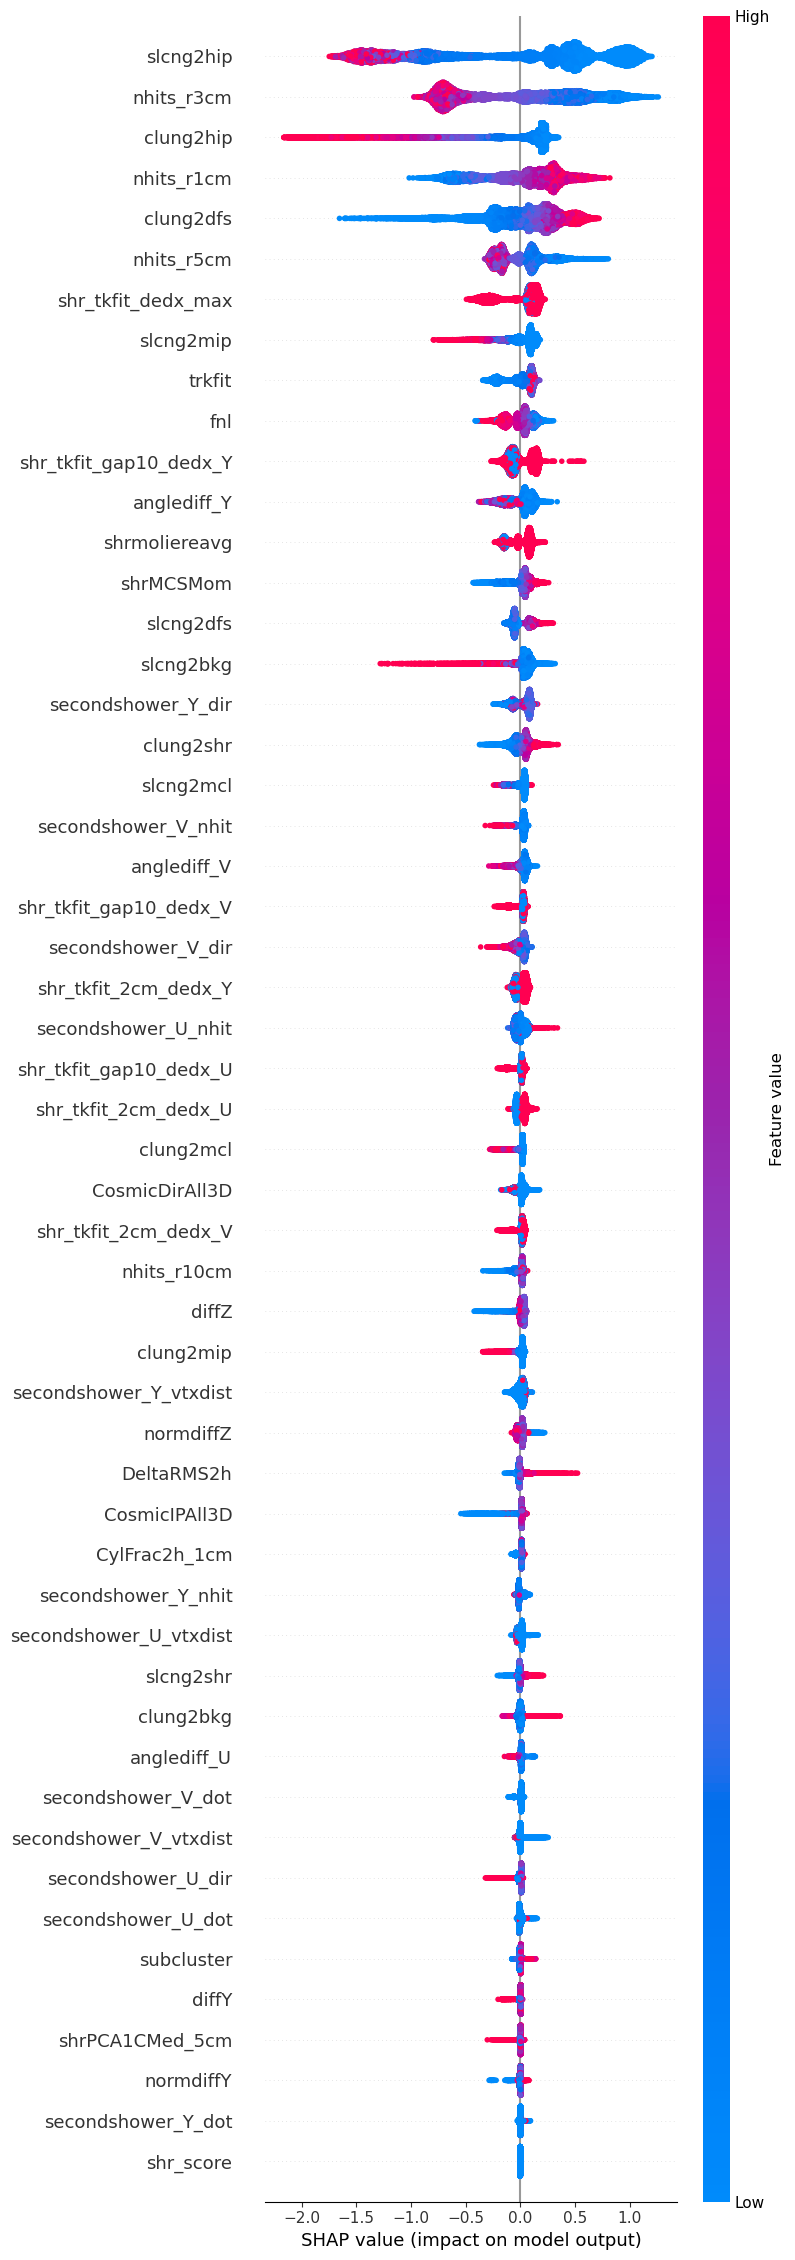

area under the precision-recall curve: 0.866571
precision score: 0.779350
recall score: 0.808916
Importance (total_gain):
slcng2hip 134676.37492710014
nhits_r3cm 33390.64074623999
clung2hip 24318.279710664003
clung2dfs 22467.869861142
slcng2bkg 18638.484672899995
nhits_r1cm 17912.51929344003
nhits_r5cm 17086.759697510006
anglediff_Y 11249.906497480006
shr_tkfit_dedx_max 10781.134587500006
slcng2mip 10386.024502399989
shr_tkfit_gap10_dedx_Y 8424.223654030005
shrMCSMom 7612.373640742002
clung2shr 4771.633488939999
trkfit 3998.367720060002
clung2bkg 3914.326741590001
fnl 3741.562366720003
slcng2mcl 3724.62164087
secondshower_V_dir 3664.3076835799993
secondshower_Y_dir 2758.60122919
shr_tkfit_2cm_dedx_Y 2633.3701758899997
slcng2dfs 2527.1738437100016
anglediff_V 2422.340281701002
secondshower_Y_vtxdist 2275.9182342500017
clung2mip 2248.6164004800007
diffZ 2216.3361278199995
shrmoliereavg 2193.96643712
nhits_r10cm 2162.3567225700003
shr_tkfit_2cm_dedx_U 2111.985100119998
CosmicDirAll3D 2018

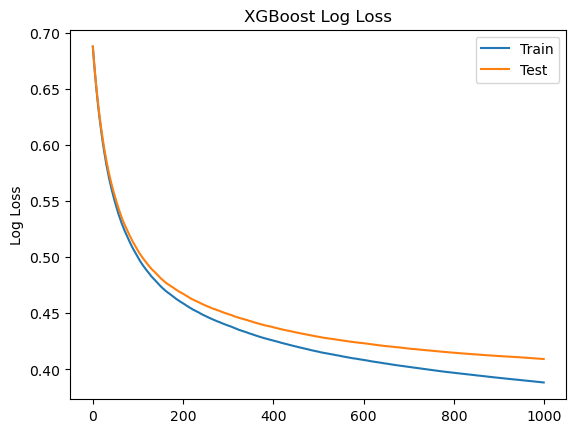

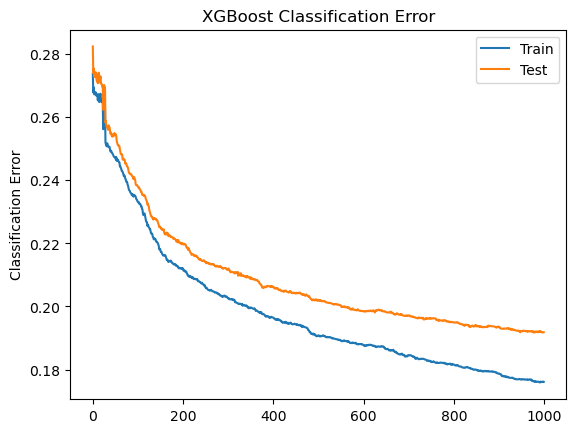

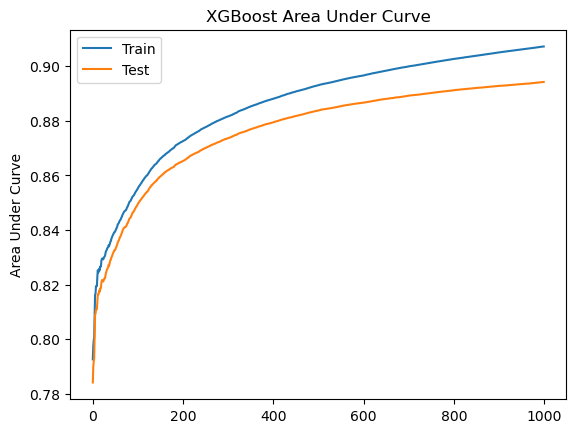

Training np...
&category==11
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl']
Validating...


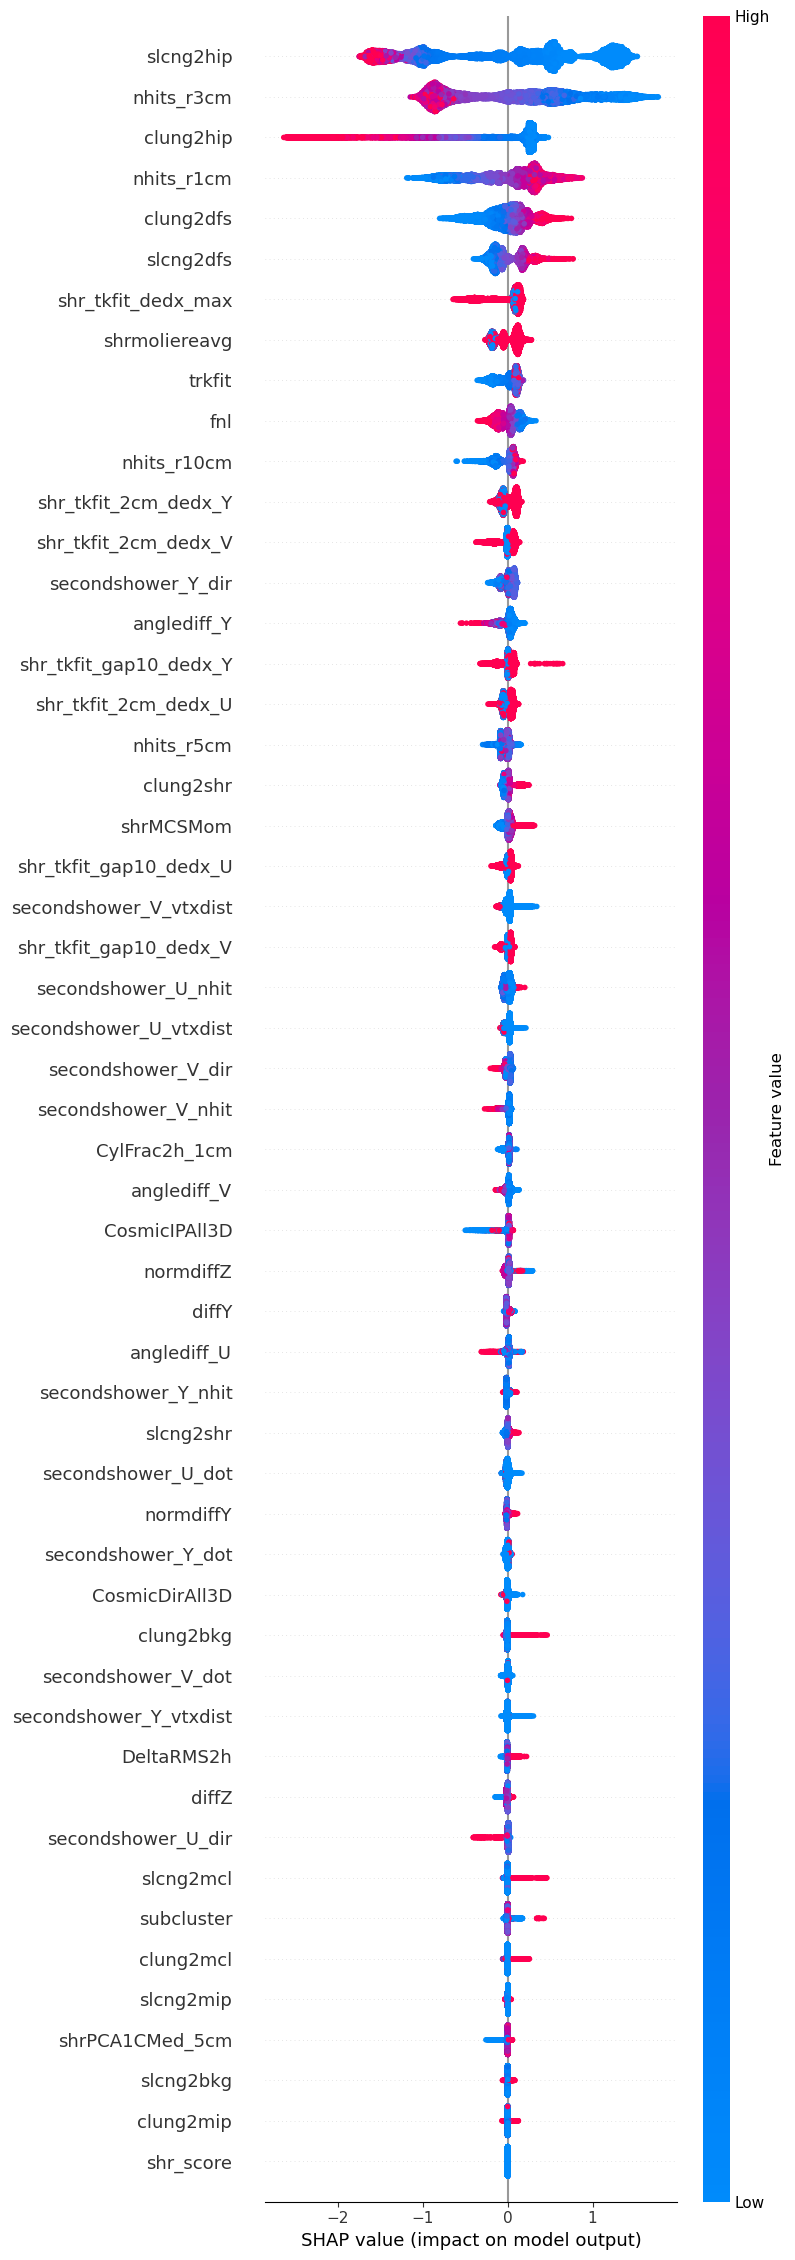

area under the precision-recall curve: 0.900974
precision score: 0.799693
recall score: 0.883091
Importance (total_gain):
slcng2hip 129953.58863433603
clung2hip 34014.69118587
nhits_r3cm 26524.560702320035
nhits_r1cm 14957.584996049998
clung2dfs 11137.904627521903
shr_tkfit_dedx_max 8868.29777518999
slcng2dfs 7401.099549004997
nhits_r5cm 3866.164661920001
fnl 3314.0051694299987
anglediff_Y 3199.274238422002
trkfit 3130.002605230003
nhits_r10cm 2944.717571619998
shr_tkfit_gap10_dedx_Y 2745.2920037500007
shr_tkfit_2cm_dedx_Y 2681.641014600001
shr_tkfit_2cm_dedx_V 2614.6768479300003
shrmoliereavg 2550.3523244
secondshower_Y_dir 2213.5502802500005
shr_tkfit_2cm_dedx_U 2209.7901841109997
shrMCSMom 1782.5798565089992
shr_tkfit_gap10_dedx_U 1640.0238394399998
CosmicIPAll3D 1491.5328367800003
clung2shr 1447.799190443
shr_tkfit_gap10_dedx_V 1366.1881592499997
secondshower_V_vtxdist 1344.9487092099987
anglediff_V 1285.0185121430002
anglediff_U 1227.0598912100002
secondshower_Y_vtxdist 1166.82603

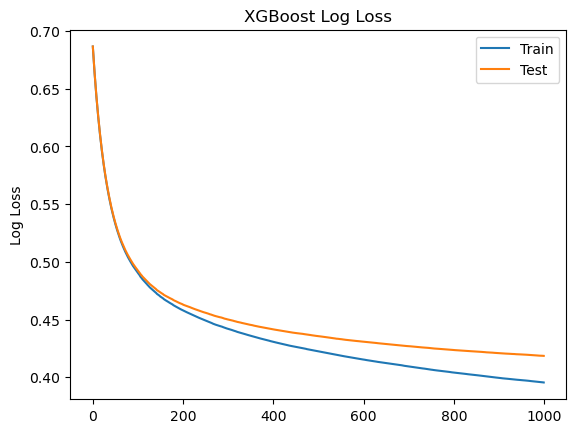

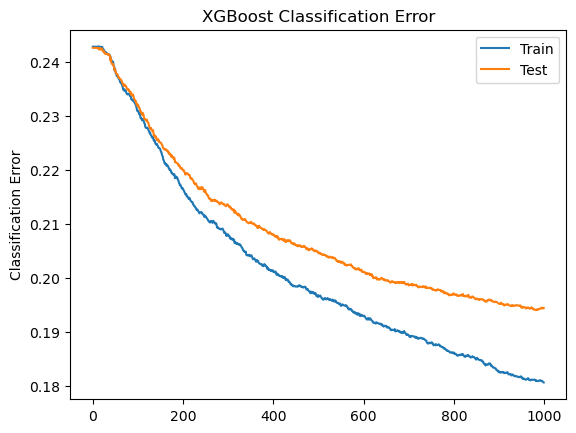

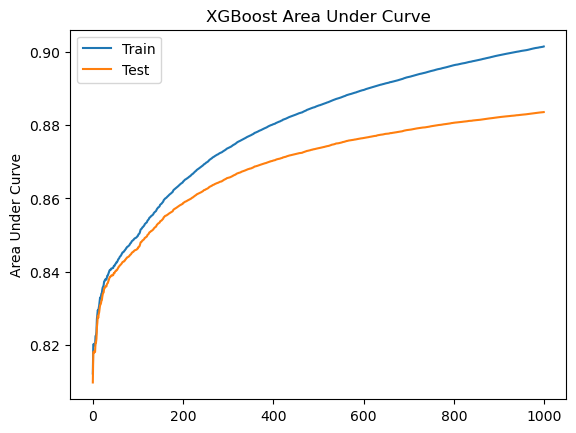

In [18]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster)
my_booster = nue_booster.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

# Extra Cosmic Rejection
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and trkfit < 0.65'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

PRESEL += ' and CosmicIPAll3D > 10.'
PRESEL += ' and shrmoliereavg < 20'
PRESEL += ' and subcluster > 5'
PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
PRESEL += ' and shr_trk_len > 20'
PRESEL += ' and CylFrac2h_1cm < 0.7'
PRESEL += ' and shrMCSMom > 20'
PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

PRESEL += ' and diffZ > -70 and diffZ < 80'
PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
PRESEL += ' and fnl > -200 and fnl < 50'

# PRESEL += ' and nonpi0_score > 0.9'
# PRESEL += ' and pi0_score > 0.5'

# PRESEL += ' and slcng2hip < 40'
# PRESEL += ' and slcng2mip < 50'
# PRESEL += ' and slcng2mcl < 40'
# PRESEL += ' and clung2hip < 50'

# Old Loose Sel.
# PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
# PRESEL += ' and n_tracks_contained == 0'
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and CosmicDirAll3D > -0.9 and CosmicDirAll3D < 0.9'
# PRESEL += ' and shrmoliereavg < 15'
# PRESEL += ' and subcluster > 4'
# PRESEL += ' and trkfit < 0.65'
# PRESEL += ' and secondshower_Y_nhit < 50'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 80'
# PRESEL += ' and shr_trk_sce_end_y > -100 and shr_trk_sce_end_y < 100 '
# PRESEL += ' and shr_trk_len < 300.'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster.labels, nue_booster.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_45_10_0pnewloosesel_mcnuequery.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [19]:
if split_type == 'simple' or split_type == 'mc_query':
    print('mc',train_nu.query(PRESEL)["train_weight"].sum())
    print('nue',train_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext.query(PRESEL)["train_weight"].sum())

if split_type == 'mc_nue_query':
    print('mc',train_nu.query(PRESEL)["train_weight"].sum())
    print('nue_signal',train_signal_nue.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',train_bkg_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext.query(PRESEL)["train_weight"].sum())

# print('mc',train_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',train_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',train_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',train_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',train_ext_25p.query(PRESEL)["train_weight"].sum())

mc 708.0
nue_signal 13827.0
nue_bkg 16859.0
dirt 29.0
ncpi0 10288.0
ext 2600.0


In [20]:
if split_type == 'simple' or split_type == 'mc_query':
    print('mc',test_nu.query(PRESEL)["train_weight"].sum())
    print('nue',test_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext.query(PRESEL)["train_weight"].sum())

if split_type == 'mc_nue_query':
    print('mc',test_nu.query(PRESEL)["train_weight"].sum())
    print('nue_signal',test_signal_nue.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',test_bkg_nue.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext.query(PRESEL)["train_weight"].sum())

# print('mc',test_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',test_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',test_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',test_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',test_ext_25p.query(PRESEL)["train_weight"].sum())

mc 699.0
nue_signal 13549.0
nue_bkg 16515.0
dirt 22.0
ncpi0 8046.0
ext 3320.0


{'anglediff_Y': 55356.114048731004, 'shr_tkfit_dedx_max': 35781.52806359999, 'shr_tkfit_gap10_dedx_Y': 38763.18980473001, 'clung2shr': 43029.87612219998, 'secondshower_V_nhit': 29636.68629292999, 'shrMCSMom': 20244.60120424999, 'shr_tkfit_2cm_dedx_Y': 17671.7584643, 'anglediff_V': 19939.382489219992, 'nhits_r5cm': 5592.895183509998, 'shrmoliereavg': 16023.122677431009, 'secondshower_Y_nhit': 13328.268390659998, 'nhits_r10cm': 31210.897793180025, 'shr_tkfit_2cm_dedx_V': 2790.1623124500006, 'secondshower_U_nhit': 21113.62958412998, 'anglediff_U': 8824.166447289994, 'slcng2hip': 24101.593170000007, 'shr_tkfit_gap10_dedx_V': 7772.571257570002, 'slcng2shr': 4647.876576130002, 'secondshower_V_vtxdist': 2334.20138589, 'clung2dfs': 21449.917837812973, 'secondshower_Y_vtxdist': 5951.261365429995, 'CylFrac2h_1cm': 9580.59136213001, 'trkfit': 7163.734120520005, 'slcng2dfs': 4523.56303603, 'clung2hip': 6962.554005610996, 'secondshower_U_vtxdist': 2227.4743071080006, 'nhits_r1cm': 5948.044902570004

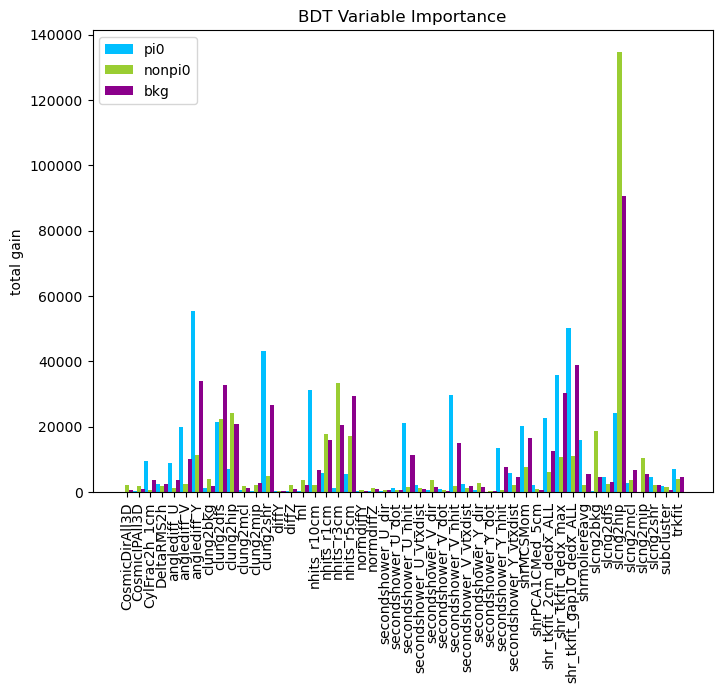

In [21]:
print(gain_imp['pi0'])
print(gain_imp['nonpi0'])
print(gain_imp['bkg'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_gap10_dedx_V']+gain_imp['pi0']['shr_tkfit_gap10_dedx_U']+gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['bkg']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_gap10_dedx_V']+gain_imp['bkg']['shr_tkfit_gap10_dedx_U']+gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_V']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_U']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_2cm_dedx_V']+gain_imp['pi0']['shr_tkfit_2cm_dedx_U']+gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_2cm_dedx_V']+gain_imp['bkg']['shr_tkfit_2cm_dedx_U']+gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_V']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_U']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['bkg'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
pi0_imp = []
nonpi0_imp = []
bkg_imp = []

for i in sorted (gain_imp['pi0'].keys()) :  
    labels.append(i)
    pi0_imp.append(gain_imp['pi0'][i])
    nonpi0_imp.append(gain_imp['nonpi0'][i])
    bkg_imp.append(gain_imp['bkg'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_imp, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_imp, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_imp, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

{'slcng2hip': 129953.58863433603, 'shr_tkfit_dedx_max': 8868.29777518999, 'nhits_r3cm': 26524.560702320035, 'clung2hip': 34014.69118587, 'clung2dfs': 11137.904627521903, 'nhits_r5cm': 3866.164661920001, 'slcng2dfs': 7401.099549004997, 'nhits_r1cm': 14957.584996049998, 'shr_tkfit_2cm_dedx_U': 2209.7901841109997, 'trkfit': 3130.002605230003, 'anglediff_Y': 3199.274238422002, 'shr_tkfit_gap10_dedx_Y': 2745.2920037500007, 'shr_tkfit_gap10_dedx_V': 1366.1881592499997, 'shr_tkfit_gap10_dedx_U': 1640.0238394399998, 'clung2bkg': 892.7305263400001, 'anglediff_V': 1285.0185121430002, 'shr_tkfit_2cm_dedx_V': 2614.6768479300003, 'shrMCSMom': 1782.5798565089992, 'slcng2mcl': 523.79243182, 'CosmicIPAll3D': 1491.5328367800003, 'fnl': 3314.0051694299987, 'slcng2shr': 806.59899517, 'secondshower_V_vtxdist': 1344.9487092099987, 'shr_tkfit_2cm_dedx_Y': 2681.641014600001, 'secondshower_V_dot': 772.5148036999999, 'secondshower_V_dir': 1077.8615488849996, 'secondshower_U_nhit': 1066.8949410110001, 'clung2mi

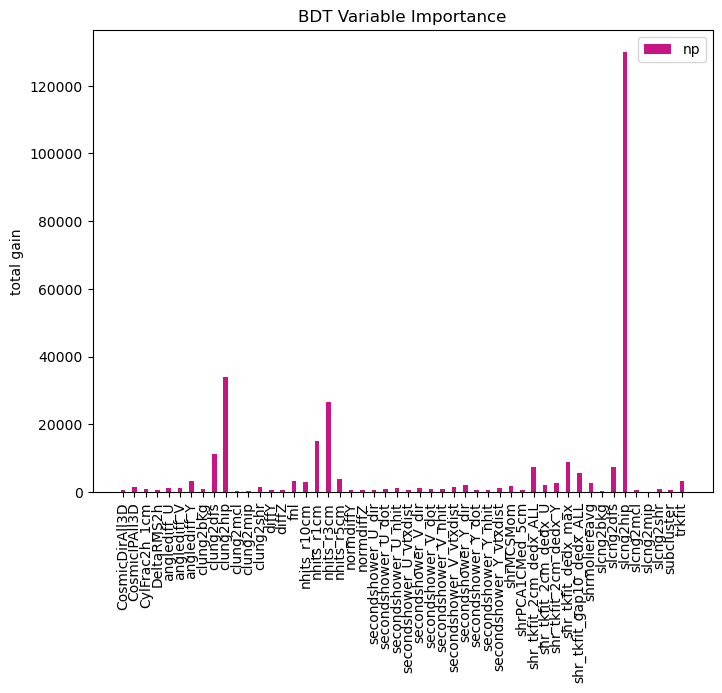

In [22]:
print(gain_imp['np'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['np']['shr_tkfit_gap10_dedx_V']+gain_imp['np']['shr_tkfit_gap10_dedx_U']+gain_imp['np']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['np']['shr_tkfit_gap10_dedx_V']
    del gain_imp['np']['shr_tkfit_gap10_dedx_U']
    del gain_imp['np']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['np']['shr_tkfit_2cm_dedx_V']+gain_imp['np']['shr_tkfit_2cm_dedx_U']+gain_imp['np']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['np']['shr_tkfit_2cm_dedx_V']

print(gain_imp['np'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
np_imp = []

for i in sorted (gain_imp['np'].keys()) :  
    labels.append(i)
    np_imp.append(gain_imp['np'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects2 = ax.bar(x, np_imp, width, label='np', color='mediumvioletred')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

In [23]:
d_pi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['pi0'], key=gain_imp['pi0'].get, reverse=True):
    d_pi0_rnk[w] = rnk
    rnk = rnk-1
print(d_pi0_rnk)

d_nonpi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['nonpi0'], key=gain_imp['nonpi0'].get, reverse=True):
    d_nonpi0_rnk[w] = rnk
    rnk = rnk-1
print(d_nonpi0_rnk)

d_bkg_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['bkg'], key=gain_imp['bkg'].get, reverse=True):
    d_bkg_rnk[w] = rnk
    rnk = rnk-1
print(d_bkg_rnk)

pi0_rnk = []
nonpi0_rnk = []
bkg_rnk = []

for i in labels:  
    pi0_rnk.append(d_pi0_rnk[i])
    nonpi0_rnk.append(d_nonpi0_rnk[i])
    bkg_rnk.append(d_bkg_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_rnk, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_rnk, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_rnk, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")

{'anglediff_Y': 50, 'shr_tkfit_gap10_dedx_ALL': 49, 'clung2shr': 48, 'shr_tkfit_dedx_max': 47, 'nhits_r10cm': 46, 'secondshower_V_nhit': 45, 'slcng2hip': 44, 'shr_tkfit_2cm_dedx_ALL': 43, 'clung2dfs': 42, 'secondshower_U_nhit': 41, 'shrMCSMom': 40, 'anglediff_V': 39, 'shrmoliereavg': 38, 'secondshower_Y_nhit': 37, 'CylFrac2h_1cm': 36, 'anglediff_U': 35, 'trkfit': 34, 'clung2hip': 33, 'secondshower_Y_vtxdist': 32, 'nhits_r1cm': 31, 'nhits_r5cm': 30, 'slcng2shr': 29, 'slcng2dfs': 28, 'slcng2mcl': 27, 'DeltaRMS2h': 26, 'secondshower_V_vtxdist': 25, 'secondshower_U_vtxdist': 24, 'shrPCA1CMed_5cm': 23, 'subcluster': 22, 'clung2bkg': 21, 'nhits_r3cm': 20, 'secondshower_U_dot': 19, 'secondshower_V_dot': 18, 'secondshower_Y_dir': 17, 'secondshower_V_dir': 16, 'clung2mcl': 15, 'diffY': 14, 'diffZ': 13, 'secondshower_U_dir': 12, 'fnl': 11, 'CosmicIPAll3D': 10, 'clung2mip': 9, 'slcng2bkg': 8, 'normdiffZ': 7, 'normdiffY': 6, 'secondshower_Y_dot': 5, 'CosmicDirAll3D': 4, 'slcng2mip': 3}
{'slcng2hip

KeyError: 'shr_tkfit_2cm_dedx_U'

{'slcng2hip': 50, 'clung2hip': 49, 'nhits_r3cm': 48, 'nhits_r1cm': 47, 'clung2dfs': 46, 'shr_tkfit_dedx_max': 45, 'shr_tkfit_2cm_dedx_ALL': 44, 'slcng2dfs': 43, 'shr_tkfit_gap10_dedx_ALL': 42, 'nhits_r5cm': 41, 'fnl': 40, 'anglediff_Y': 39, 'trkfit': 38, 'nhits_r10cm': 37, 'shr_tkfit_2cm_dedx_Y': 36, 'shrmoliereavg': 35, 'secondshower_Y_dir': 34, 'shr_tkfit_2cm_dedx_U': 33, 'shrMCSMom': 32, 'CosmicIPAll3D': 31, 'clung2shr': 30, 'secondshower_V_vtxdist': 29, 'anglediff_V': 28, 'anglediff_U': 27, 'secondshower_Y_vtxdist': 26, 'secondshower_V_dir': 25, 'secondshower_U_nhit': 24, 'secondshower_V_nhit': 23, 'clung2bkg': 22, 'slcng2shr': 21, 'secondshower_V_dot': 20, 'secondshower_U_dot': 19, 'CylFrac2h_1cm': 18, 'normdiffZ': 17, 'secondshower_U_vtxdist': 16, 'CosmicDirAll3D': 15, 'DeltaRMS2h': 14, 'diffY': 13, 'secondshower_Y_nhit': 12, 'secondshower_U_dir': 11, 'normdiffY': 10, 'slcng2mcl': 9, 'shrPCA1CMed_5cm': 8, 'diffZ': 7, 'subcluster': 6, 'secondshower_Y_dot': 5, 'clung2mcl': 4, 'slcn

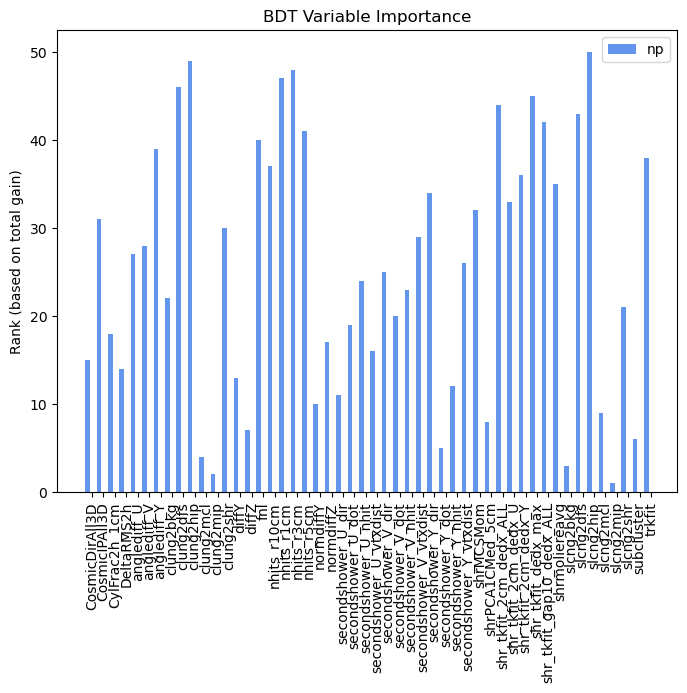

: 

In [ ]:
d_np_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['np'], key=gain_imp['np'].get, reverse=True):
    d_np_rnk[w] = rnk
    rnk = rnk-1
print(d_np_rnk)

np_rnk = []

for i in labels:  
    np_rnk.append(d_np_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, np_rnk, width, label='np', color='cornflowerblue')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")